In [1]:
# IMPORTS
from FuncionesAUX import *
from pathlib import Path

import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import rioxarray as rxr

In [2]:
# RUTAS DE TRABAJO
BASE = Path(r"C:\Users\Gambo\Documents\Master Aaron\TFM UCM")
DATA = BASE / "Data"

ruta_firespain = DATA / "firespain025_WGS84.nc"
ruta_era5 = DATA / "era5" / "era5_land_clean.nc"
ruta_mdt = DATA / "MDT" / "mdt_spain.tif"
ruta_civio = DATA / "CIVIO" / "fires-all.csv"

In [3]:
fr25 = xr.open_dataset(ruta_firespain)

print_header("FIRESPAIN")
print(f"\nPeriodo temporal : desde {str(fr25.time.min().values)[:10]} hasta {str(fr25.time.max().values)[:10]}")
print(f"Nº de días       : {fr25.sizes['time']:,}")
print(f"Nº de latitudes  : {fr25.sizes['latitude']}")
print(f"Nº de longitudes : {fr25.sizes['longitude']}")
print(f"Resolución       : 0.25°")
print()

print("Variables disponibles:")
for var in fr25.data_vars:
    print(f"- {var}")

FIRESPAIN

Periodo temporal : desde 1983-01-02 hasta 2022-01-01
Nº de días       : 14,245
Nº de latitudes  : 34
Nº de longitudes : 54
Resolución       : 0.25°

Variables disponibles:
- ba


Q25 = 391.31 ha
Q50 = 1757.61 ha
Q75 = 5687.16 ha


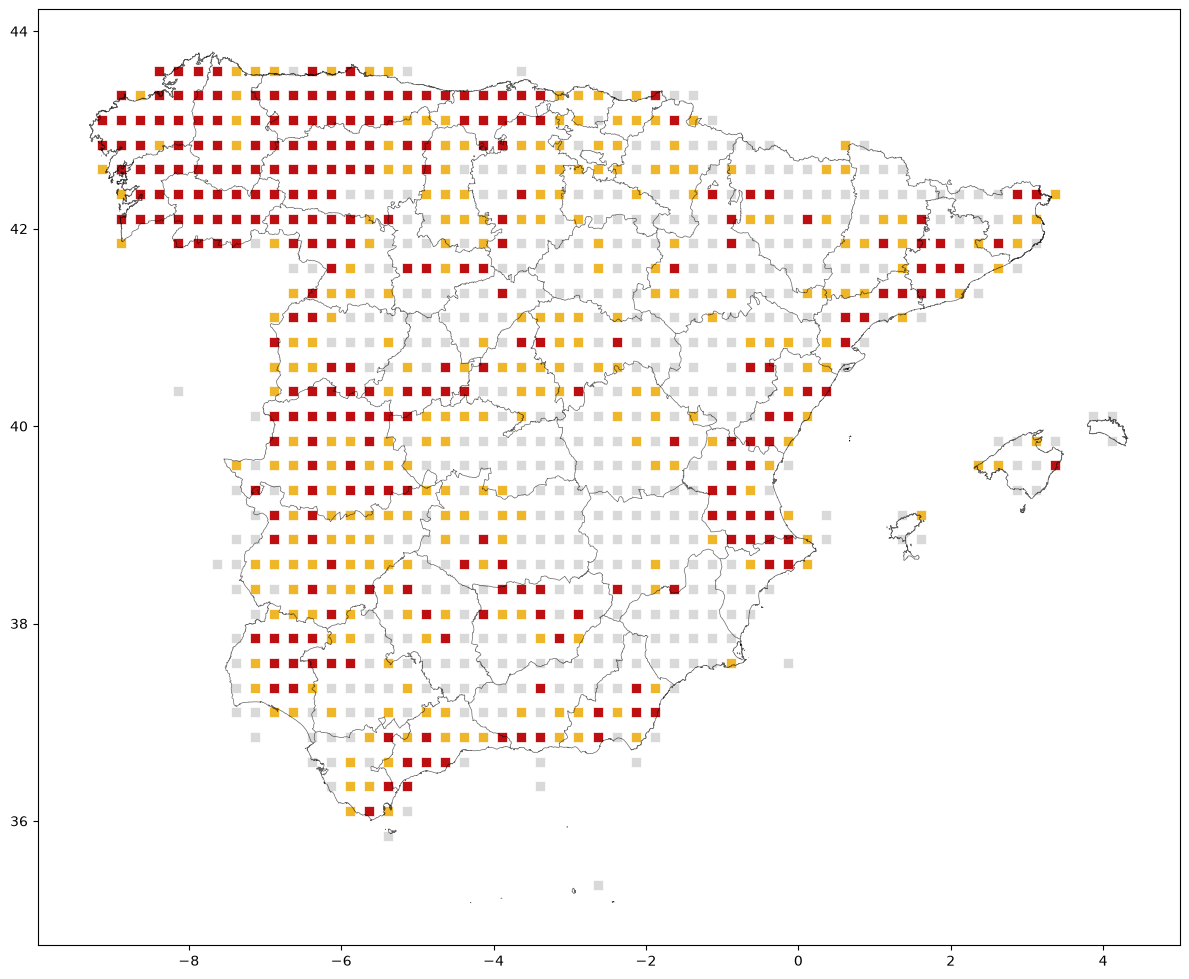

In [34]:
# ============================================================
# MAPA — HOTSPOTS HISTÓRICOS DE ÁREA QUEMADA
# FIRESPAIN 1983–2022
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------
# 1. Acumulado temporal de área quemada
# ------------------------------------------------------------

ba_acumulado = ba.sum(dim="time")

# Convertir a DataFrame
df_hotspots = ba_acumulado.to_dataframe(
    name="area_quemada"
).reset_index()

# Eliminar valores NaN
df_hotspots = df_hotspots.dropna(subset=["area_quemada"])

# ------------------------------------------------------------
# 2. Calcular cuantiles SOLO sobre celdas con área quemada
# ------------------------------------------------------------

valores_positivos = df_hotspots.loc[df_hotspots["area_quemada"] > 0, "area_quemada"]
q25 = valores_positivos.quantile(0.25)
q50 = valores_positivos.quantile(0.50)
q75 = valores_positivos.quantile(0.75)
print(f"Q25 = {q25:.2f} ha")
print(f"Q50 = {q50:.2f} ha")
print(f"Q75 = {q75:.2f} ha")

# ------------------------------------------------------------
# 3. Clasificar cada celda
# ------------------------------------------------------------

df_hotspots.loc[(df_hotspots["area_quemada"] > 15) & (df_hotspots["area_quemada"] <= q50), "categoria"] = "Baja representatividad"
df_hotspots.loc[(df_hotspots["area_quemada"] > q50) & (df_hotspots["area_quemada"] <= q75), "categoria"] = "Media representatividad"
df_hotspots.loc[df_hotspots["area_quemada"] > q75, "categoria"] = "Alta representatividad"

# ------------------------------------------------------------
# 4. Colores
# ------------------------------------------------------------

colores = {
    "Baja representatividad": "#d9d9d9",
    "Media representatividad": "#eeb628",
    "Alta representatividad": "#bd0f12"
}

# ------------------------------------------------------------
# 5. Crear figura
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 12))
for categoria in [
    "Baja representatividad",
    "Media representatividad",
    "Alta representatividad"
]:

    datos = df_hotspots[
        df_hotspots["categoria"] == categoria
    ]

    ax.scatter(
        datos["longitude"],
        datos["latitude"],
        color=colores[categoria],
        s=55,
        marker="s",
        edgecolor="white",
        linewidth=0.5,
        label=categoria,
        zorder=2
    )

plot_provincias(ax)
plt.tight_layout()
plt.show()